# Brain Tumor MRI Classification - Part 2

**Author:** Kodanda Challa  
**Student ID:** 25727  
**Date:** 2026

## Project Overview

This notebook implements a **Convolutional Neural Network (CNN)** for brain tumor classification and uses **Grad-CAM (Gradient-weighted Class Activation Maps)** to visualize which regions of MRI images the model focuses on when making predictions.

---

## Key Concepts

### **Convolutional Neural Networks (CNNs)**
- **What:** Deep learning architecture specifically designed for image processing
- **Why:** Learns hierarchical features from raw pixels (edges → textures → patterns → objects)
- **How:** Uses convolutional layers to extract spatial features, pooling to reduce dimensions

### **Grad-CAM (Gradient-weighted Class Activation Maps)**
- **What:** Explainability technique showing which image regions influenced predictions
- **Why:** Makes "black box" neural networks interpretable for medical diagnosis
- **How:** Computes gradients of predicted class w.r.t. convolutional feature maps
- **Output:** Heatmap where red = important, blue = unimportant regions

---

## Project Workflow

```
Environment Setup & Configuration
↓
Data Loading & Preprocessing
↓
Exploratory Data Analysis
↓
CNN Model Construction (Functional API)
↓
Model Training with Callbacks
↓
Model Evaluation & Metrics
↓
Grad-CAM Heatmap Generation
↓
Visualization & Interpretation
↓
Summary & Conclusions
```

## 1. Environment Setup

Import necessary libraries and verify versions.

In [1]:
# ============================================================================
# IMPORTS - All necessary libraries
# ============================================================================

import os
import time
import warnings
import numpy as np
import imutils
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    Dropout, GlobalAveragePooling2D, Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Metrics
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

# Suppress warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")
print(f"\nEnvironment Information:")
print(f"  TensorFlow version: {tf.__version__}")
print(f"  Keras version: {tf.keras.__version__}")
print(f"  NumPy version: {np.__version__}")
print(f"  GPU Available: {tf.config.list_physical_devices('GPU')}")

✓ All libraries imported successfully

Environment Information:
  TensorFlow version: 2.21.0
  Keras version: 3.14.1
  NumPy version: 2.4.6
  GPU Available: []


## 2. Configuration & Hyperparameters

Define all settings in one place for easy modification.

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Track execution time
PROGRAM_START = time.perf_counter()

# ===== Dataset Configuration =====
DATASET_PATH = "Dataset_MRI"
TRAIN_DIR = os.path.join(DATASET_PATH, 'Training')
TEST_DIR = os.path.join(DATASET_PATH, 'Testing')

# Class labels
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

# ===== Image Processing =====
IMG_SIZE = 224                          # Target image size: 224x224
IMG_CHANNELS = 3                        # RGB images
NORMALIZE_PIXEL_VALUES = True           # Scale to [0, 1]

# ===== Training Hyperparameters =====
BATCH_SIZE = 32                         # Batch size for training
EPOCHS = 15                            # Maximum number of epochs
VALIDATION_SPLIT = 0.3                  # Use 30% of training data for validation
LEARNING_RATE = 0.001                  # Initial learning rate

# ===== Callbacks Configuration =====
EARLY_STOPPING_PATIENCE = 5             # Stop if no improvement for 5 epochs
EARLY_STOPPING_MONITOR = 'val_loss'    # Monitor validation loss

# Learning rate reduction reduces learning rate if validation loss plateaus
LR_REDUCTION_FACTOR = 0.3                 # Multiply learning rate by this factor
LR_REDUCTION_PATIENCE = 2                 # Epochs to wait before reducing learning rate
MIN_LEARNING_RATE = 1e-7                  # Minimum learning rate (prevent too small values)


# ===== Model Checkpoint =====
MODEL_CHECKPOINT_PATH = 'best_cnn_model.h5'
MODEL_CHECKPOINT_MONITOR = 'val_accuracy'


# ===== Grad-CAM Configuration =====
GRADCAM_LAYER_NAME = 'last_conv'        # Name of conv layer for Grad-CAM
NUM_GRADCAM_SAMPLES = 4                 # Number of samples to visualize

# ===== Reproducibility =====
RANDOM_SEED = 32
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ===== Visualization =====
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Configuration loaded")
print(f"\nDataset Configuration:")
print(f"  Image size: {IMG_SIZE}×{IMG_SIZE}×{IMG_CHANNELS}")
print(f"  Classes: {NUM_CLASSES} ({', '.join(CLASSES)})")
print(f"\nTraining Configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Validation split: {VALIDATION_SPLIT*100:.0f}%")

✓ Configuration loaded

Dataset Configuration:
  Image size: 224×224×3
  Classes: 4 (glioma, meningioma, notumor, pituitary)

Training Configuration:
  Batch size: 32
  Epochs: 15
  Learning rate: 0.001
  Validation split: 30%


## 3. Data Loading & Preprocessing

Load images from disk, handle different formats, and normalize pixel values.

In [ ]:
# ============================================================================
# DATA LOADING FUNCTION
# ============================================================================

def load_images_from_directory(data_dir, classes, img_size=128, normalize=True):
    """
    Load and preprocess images from a directory structure.
    
    Handles:
    - Multiple image formats (.jpg, .png, .jpeg)
    - Both grayscale and RGB images
    - Resizing to consistent dimensions
    - Normalization to [0, 1] range
    
    Parameters:
    -----------
    data_dir : str
        Root directory containing class subdirectories
    classes : list
        List of class names (must match subdirectory names)
    img_size : int
        Target size for square images (img_size × img_size)
    normalize : bool
        Whether to normalize pixel values to [0, 1]
    
    Returns:
    --------
    images : np.ndarray
        Array of shape (n_samples, img_size, img_size, 3)
    labels : np.ndarray
        Array of class names (strings)
    """
    images = []
    labels = []
    failed_images = 0
    
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        
        # Check if directory exists
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory not found - {class_dir}")
            continue
        
        # Get list of image files
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp', '.tiff'))]
        
        print(f"Loading {class_name}: ", end="")
        
        # Load each image
        for filename in image_files:
            filepath = os.path.join(class_dir, filename)
            
            try:
                # Read image with OpenCV
                img = cv2.imread(filepath)

                # Transform images
                img  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # Optional preprocessing steps (uncomment if needed), but no improvement in accuracy
                # img   = cv2.GaussianBlur(img, (5, 5), 0)
                # img = cv2.threshold(img, 45, 255, cv2.THRESH_BINARY)[1]
                # img = cv2.erode(img, None, iterations = 2)
                # img = cv2.dilate(img, None, iterations = 2)

                # Crop to brain region using contours
                # contours   = cv2.findContours(img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                # contours   = imutils.grab_contours(contours)
                # c = max(contours, key = cv2.contourArea)
                # extLeft   = tuple(c[c[:, :, 0].argmin()])[0]
                # extRight  = tuple(c[c[:, :, 0].argmax()])[0]
                # extTop    = tuple(c[c[:, :, 1].argmin()])[0]
                # extBottom = tuple(c[c[:, :, 1].argmax()])[0]
                # img = img[extTop[1]: extBottom[1], extLeft[0]:extRight[0]] 
                
                # Handle failed reads
                if img is None:
                    failed_images += 1
                    continue
                
                # Handle different image formats
                if len(img.shape) == 2:  # Grayscale
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                else:  # Color (BGR)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Resize to target size
                img = cv2.resize(img, (img_size, img_size))              
                
                # Normalize pixel values
                if normalize:
                    img = img.astype('float32') / 255.0
                
                images.append(img)
                labels.append(class_name)
                
            except Exception as e:
                failed_images += 1
                continue
        
        print(f"{len([l for l in labels if l == class_name])} images")
    
    if failed_images > 0:
        print(f"⚠ Failed to load {failed_images} images")
    
    return np.array(images), np.array(labels)


# Load training and testing data
print("Loading training data...")
X_train, y_train_raw = load_images_from_directory(
    TRAIN_DIR, CLASSES, IMG_SIZE, normalize=NORMALIZE_PIXEL_VALUES
)

print("\nLoading testing data...")
X_test, y_test_raw = load_images_from_directory(
    TEST_DIR, CLASSES, IMG_SIZE, normalize=NORMALIZE_PIXEL_VALUES
)


# ===Get indices and shuffle them===
indices = np.arange(len(X_train))
# np.random.seed(RANDOM_SEED)  # Ensure reproducibility
np.random.shuffle(indices)

# Apply the same shuffle to both X_train and y_train_raw
X_train_shuffled = X_train[indices]
y_train_shuffled = y_train_raw[indices]  # or y_train_raw[indices] if it's a 1D array
# Use the shuffled data for training
X_train = X_train_shuffled
y_train_raw = y_train_shuffled

# apply the same shuffle to both X_test and y_test_raw
indices = np.arange(len(X_test))
np.random.shuffle(indices)
X_test_shuffled = X_test[indices]
y_test_shuffled = y_test_raw[indices]  # or y_test_raw[indices] if it's a 1D array
X_test = X_test_shuffled
y_test_raw = y_test_shuffled

# # reduce the training data to 2000 samples
# X_train = X_train[:2000]
# y_train_raw = y_train_raw[:2000]

# # reduce the testing data to 400 samples
# X_test = X_test[:400]
# y_test_raw = y_test_raw[:400]


print(f"\n✓ Data loading complete")
print(f"  Training set shape: {X_train.shape}  {y_train_raw.shape}")
print(f"  Testing set shape: {X_test.shape} {y_test_raw.shape}")
print(f"  Data type: {X_train.dtype}")
print(f"  Pixel value range: [{X_train.min():.3f}, {X_train.max():.3f}]")

Loading training data...
Loading glioma: 1400 images
Loading meningioma: 1400 images
Loading notumor: 1400 images
Loading pituitary: 1400 images

Loading testing data...
Loading glioma: 400 images
Loading meningioma: 400 images
Loading notumor: 400 images
Loading pituitary: 400 images

✓ Data loading complete
  Training set shape: (5600, 224, 224, 3)  (5600,)
  Testing set shape: (1600, 224, 224, 3) (1600,)
  Data type: float32
  Pixel value range: [0.000, 1.000]


## 4. Label Encoding & Categorical Conversion

Encode string labels to numeric values and create one-hot encodings.

In [4]:
# ============================================================================
# LABEL ENCODING
# ============================================================================

# Initialize label encoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

# Convert to one-hot encoding (categorical) for neural network
y_train_categorical = to_categorical(y_train_encoded, NUM_CLASSES)
y_test_categorical = to_categorical(y_test_encoded, NUM_CLASSES)

print("✓ Label encoding complete")
print(f"\nLabel Mapping:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name:12s} → {idx}")

✓ Label encoding complete

Label Mapping:
  glioma       → 0
  meningioma   → 1
  notumor      → 2
  pituitary    → 3


## 5. Exploratory Data Analysis (EDA)

Visualize sample images to understand data characteristics.

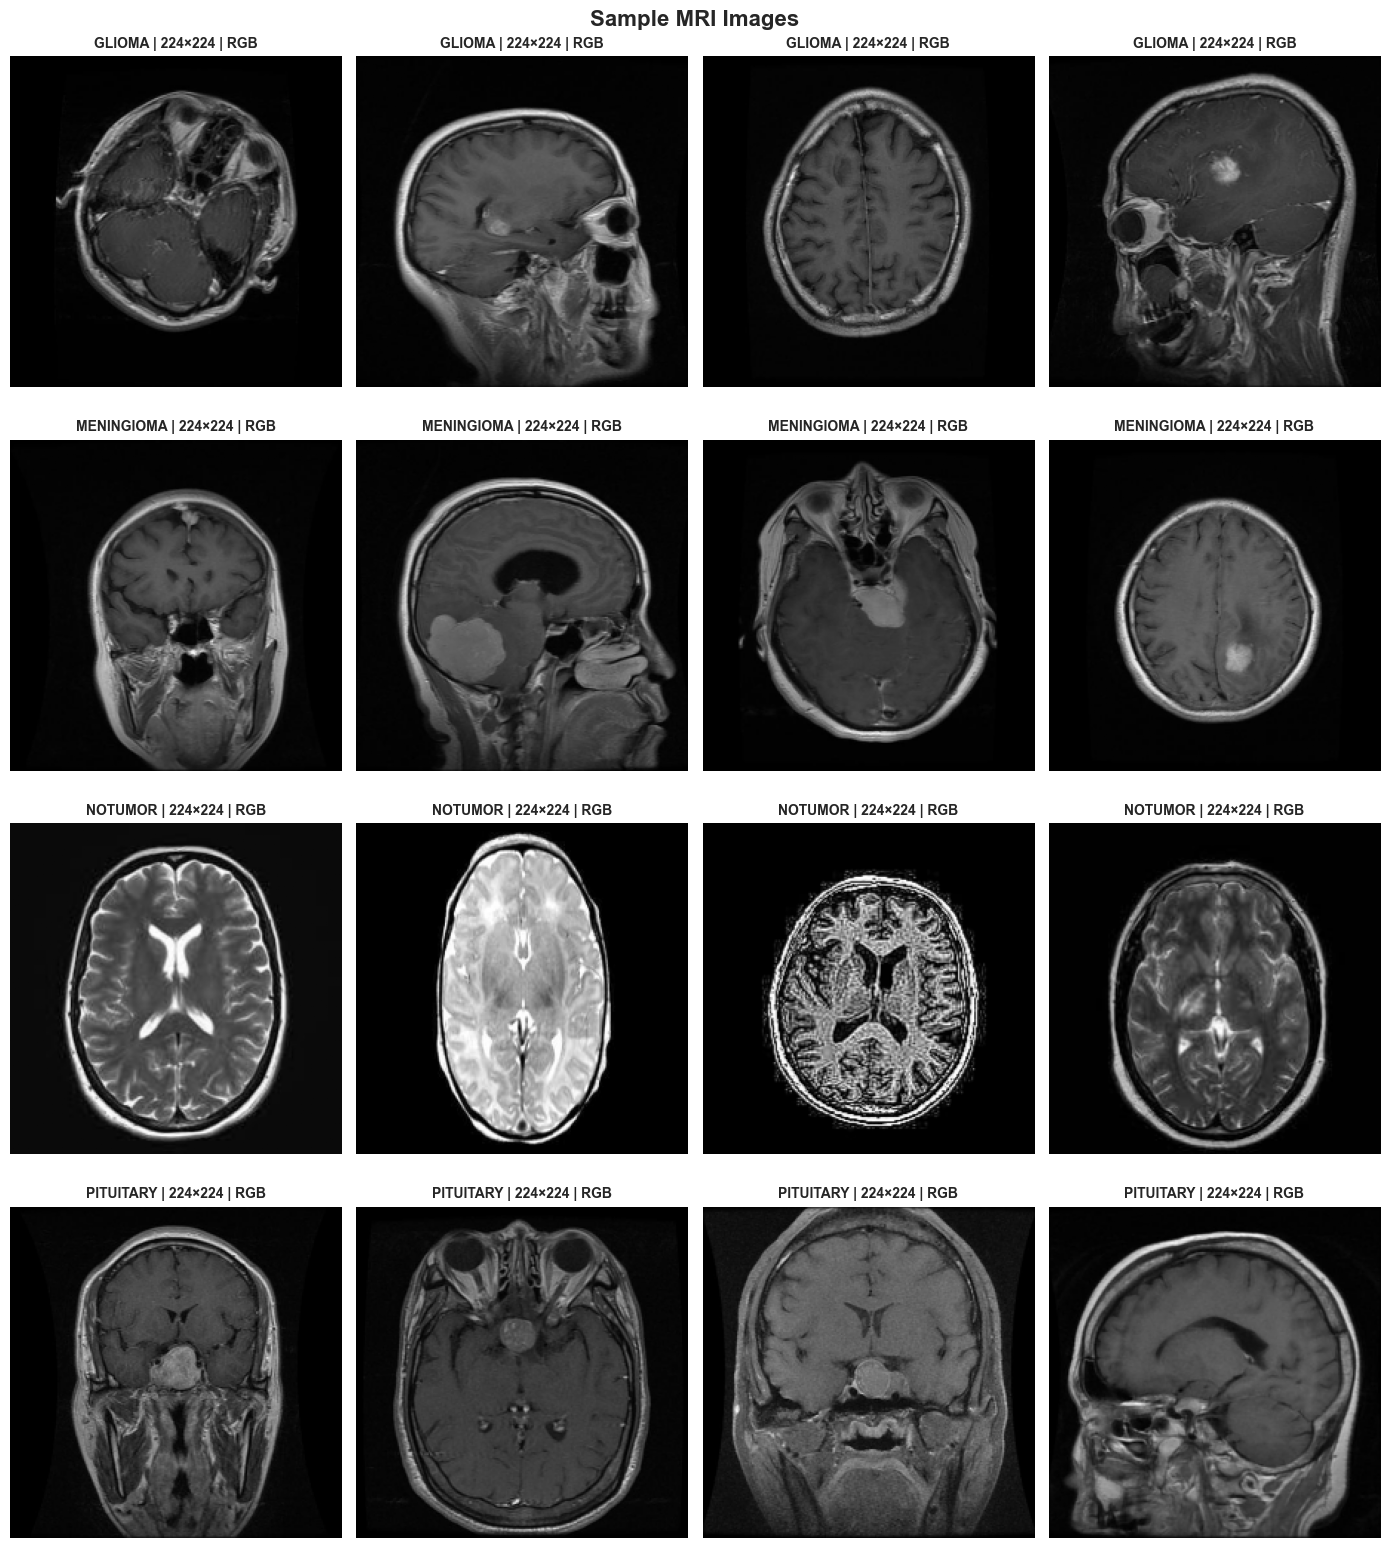


✓ Sample images displayed


In [5]:
# ============================================================================
# VISUALIZE: Sample images from each class
# ============================================================================

fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, 4*NUM_CLASSES))
fig.suptitle('Sample MRI Images', fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASSES):
    # Get indices for this class
    class_indices = np.where(y_train_raw == class_name)[0]
    
    # Select 4 random samples
    sample_indices = np.random.choice(class_indices, size=4, replace=False)
    
    for col, img_idx in enumerate(sample_indices):
        ax = axes[class_idx, col]
        
        # Display image
        image = X_train[img_idx]
        is_grayscale = image.ndim == 2 or image.shape[-1] == 1
        ax.imshow(image.squeeze(), cmap='gray' if is_grayscale else None)
        
        # Add title with image type
        img_type = 'Grayscale' if is_grayscale else 'RGB'
        ax.set_title(
            f'{class_name.upper()} | {IMG_SIZE}×{IMG_SIZE} | {img_type}',
            fontsize=10,
            fontweight='bold'
        )
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Sample images displayed")

## 6. CNN Model Construction (Functional API)

Build a convolutional neural network using Keras Functional API.

**Architecture Overview**

```
Input (224×224×3)
↓
[Block 1] Conv2D(32) → BatchNorm → Conv2D(32) → BatchNorm → MaxPool → Dropout(0.25)
↓
[Block 2] Conv2D(64) → BatchNorm → Conv2D(64) → BatchNorm → MaxPool → Dropout(0.25)
↓
[Block 3] Conv2D(256) → BatchNorm → Conv2D(256) → BatchNorm ← Grad-CAM layer
↓
MaxPool → Dropout(0.50)
↓
GlobalAveragePooling2D
↓
Dense(256, ReLU) → Dropout(0.50)
↓
Dense(4, Softmax) [Output]

6 convolutional layers [2 conv layers per block] and 2 dense layers = Total 8 layers
```

### Key Design Decisions

1. **Functional API**: Allows direct access to layer outputs for Grad-CAM
2. **Batch Normalization**: Stabilizes training and enables higher learning rates
3. **MaxPooling**: Reduces spatial dimensions while preserving important features
4. **Dropout**: Prevents overfitting by randomly disabling neurons
5. **GlobalAveragePooling**: Reduces feature maps to a vector without dense layers
6. **Named Conv Layer**: "last_conv" layer used for Grad-CAM visualization

In [6]:
# ============================================================================
# CNN MODEL CONSTRUCTION - Functional API (Optimized Version)
# ============================================================================

print("Building optimized CNN model using Functional API...\n")
# 2 convolutional layers per block, total 6 convolutional layers and 2 dense layers: total 8 layers 
# batch normalization, and dropout for regularization

# Input layer
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS), name='input_layer')

# ===== Block 1 =====
# Learn low-level features
x = Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1_1')(inputs)
x = BatchNormalization(name='bn1_1')(x)
x = Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1_2')(x)
x = BatchNormalization(name='bn1_2')(x)
x = MaxPooling2D(pool_size=(2, 2), name='pool1')(x)
x = Dropout(0.25, name='dropout1')(x)

# ===== Block 2 =====
# Learn mid-level features
x = Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2_1')(x)
x = BatchNormalization(name='bn2_1')(x)
x = Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2_2')(x)
x = BatchNormalization(name='bn2_2')(x)
x = MaxPooling2D(pool_size=(2, 2), name='pool2')(x)
x = Dropout(0.25, name='dropout2')(x)

# ===== Block 3 =====
# Final deep feature extractor
x = Conv2D(256, (3, 3), padding='same', activation='relu', name='conv4_1')(x)
x = BatchNormalization(name='bn4_1')(x)

# Named final convolution layer for Grad-CAM
x = Conv2D(256, (3, 3), padding='same', activation='relu',
           name=GRADCAM_LAYER_NAME)(x)
x = BatchNormalization(name='bn4_2')(x)

x = MaxPooling2D(pool_size=(2, 2), name='pool4')(x)
x = Dropout(0.50, name='dropout4')(x)

# ===== Global Average Pooling =====
x = GlobalAveragePooling2D(name='global_avg_pool')(x)

# ===== Dense classifier =====
x = Dense(256, activation='relu', name='dense1')(x)
x = Dropout(0.50, name='dropout5')(x)

# Output layer
outputs = Dense(NUM_CLASSES, activation='softmax', name='output_layer')(x)

# Create model
model = Model(inputs=inputs, outputs=outputs, name='CNN_Network')

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Optimized model constructed successfully!\n")
model.summary()

Building optimized CNN model using Functional API...


✓ Optimized model constructed successfully!



Model: "CNN_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 56, 56, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_1 (BatchNormalization)      │ (None, 56, 56, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_2 (BatchNormalization)      │ (None, 56, 56, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,996 (3.33 MB)

 Trainable params: 871,588 (3.32 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 7. Model Training

Train the CNN with callbacks for early stopping and model checkpointing.

In [7]:
# ============================================================================
# TRAINING WITH CALLBACKS
# ============================================================================

# Define callbacks
callbacks = [
    EarlyStopping(
        monitor=EARLY_STOPPING_MONITOR,         # Monitor validation loss
        patience=EARLY_STOPPING_PATIENCE,       # Wait N epochs before stopping
        restore_best_weights=True,              # Restore best weights after stopping
        verbose=1                               # Print messages when stopping
    ),

    ReduceLROnPlateau(
        monitor=EARLY_STOPPING_MONITOR,        # Monitor same metric
        factor=LR_REDUCTION_FACTOR,            # Multiply LR by this factor
        patience=LR_REDUCTION_PATIENCE,        # Wait N epochs before reducing
        min_lr=MIN_LEARNING_RATE,              # Don't go below this LR
        verbose=1                              # Print messages
    ),

    ModelCheckpoint(
        MODEL_CHECKPOINT_PATH,                  # Save best model to this file
        monitor=MODEL_CHECKPOINT_MONITOR,       # Monitor validation accuracy
        save_best_only=True,                    # Only save if it's the best so far
        verbose=0                               # Don't print messages 
    )
]

print("="*70)
print("TRAINING CNN MODEL")
print("="*70)
print(f"Training samples: {len(X_train)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Validation split: {VALIDATION_SPLIT*100:.0f}%")
print(f"Callbacks: EarlyStopping (patience={EARLY_STOPPING_PATIENCE}), ModelCheckpoint")
print("="*70)
print()

# Train model
training_start = time.time()
history = model.fit(
    X_train, y_train_categorical,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
training_time = time.time() - training_start

actual_epochs = len(history.history['loss'])
print(f"\n✅ Training completed!")
print(f"   Actual epochs: {actual_epochs} (stopped by EarlyStopping)")
print(f"   Training time: {training_time:.2f} seconds")
print(f"   Best validation loss: {min(history.history['val_loss']):.4f}")
print(f"   Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

TRAINING CNN MODEL
Training samples: 5600
Batch size: 32
Epochs: 15
Validation split: 30%
Callbacks: EarlyStopping (patience=5), ModelCheckpoint

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6430 - loss: 0.9221

123/123 ━━━━━━━━━━━━━━━━━━━━ 502s 4s/step - accuracy: 0.7043 - loss: 0.7798 - val_accuracy: 0.2439 - val_loss: 2.1995 - learning_rate: 0.0010
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7587 - loss: 0.6112

123/123 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 0.7744 - loss: 0.5738 - val_accuracy: 0.3534 - val_loss: 5.4664 - learning_rate: 0.0010
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8231 - loss: 0.4897 
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
123/123 ━━━━━━━━━━━━━━━━━━━━ 1295s 11s/step - accuracy: 0.8331 - loss: 0.4572 - val_accuracy: 0.2445 - val_loss: 9.4555 - learning_rate: 0.0010
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 337s 3s/step - accuracy: 0.8660 - loss: 0.3614 - val_accuracy: 0.2647 - val_loss: 5.8666 - learning_rate: 3.0000e-04
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8688 - loss: 0.3586

123/123 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.8717 - loss: 0.3445 - val_accuracy: 0.6883 - val_loss: 1.0044 - learning_rate: 3.0000e-04
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8791 - loss: 0.3334

123/123 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.8826 - loss: 0.3211 - val_accuracy: 0.7769 - val_loss: 0.5751 - learning_rate: 3.0000e-04
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8821 - loss: 0.3232

123/123 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.8826 - loss: 0.3099 - val_accuracy: 0.8584 - val_loss: 0.3837 - learning_rate: 3.0000e-04
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 343s 3s/step - accuracy: 0.8913 - loss: 0.2910 - val_accuracy: 0.8584 - val_loss: 0.3547 - learning_rate: 3.0000e-04
Epoch 9/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 346s 3s/step - accuracy: 0.8992 - loss: 0.2759 - val_accuracy: 0.6591 - val_loss: 0.9862 - learning_rate: 3.0000e-04
Epoch 10/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9005 - loss: 0.2832
Epoch 10: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
123/123 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.9056 - loss: 0.2618 - val_accuracy: 0.8412 - val_loss: 0.3977 - learning_rate: 3.0000e-04
Epoch 11/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8989 - loss: 0.2681

123/123 ━━━━━━━━━━━━━━━━━━━━ 456s 3s/step - accuracy: 0.9109 - loss: 0.2416 - val_accuracy: 0.8751 - val_loss: 0.3223 - learning_rate: 9.0000e-05
Epoch 12/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9123 - loss: 0.2493

123/123 ━━━━━━━━━━━━━━━━━━━━ 956s 8s/step - accuracy: 0.9166 - loss: 0.2297 - val_accuracy: 0.8995 - val_loss: 0.2636 - learning_rate: 9.0000e-05
Epoch 13/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9170 - loss: 0.2296

123/123 ━━━━━━━━━━━━━━━━━━━━ 535s 4s/step - accuracy: 0.9196 - loss: 0.2134 - val_accuracy: 0.9048 - val_loss: 0.2494 - learning_rate: 9.0000e-05
Epoch 14/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9188 - loss: 0.2221

123/123 ━━━━━━━━━━━━━━━━━━━━ 485s 4s/step - accuracy: 0.9194 - loss: 0.2120 - val_accuracy: 0.9054 - val_loss: 0.2517 - learning_rate: 9.0000e-05
Epoch 15/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9268 - loss: 0.2159
Epoch 15: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
123/123 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.9247 - loss: 0.2044 - val_accuracy: 0.8917 - val_loss: 0.2846 - learning_rate: 9.0000e-05
Restoring model weights from the end of the best epoch: 13.

✅ Training completed!
   Actual epochs: 15 (stopped by EarlyStopping)
   Training time: 7449.35 seconds
   Best validation loss: 0.2494
   Best validation accuracy: 0.9054


### 7.1 Training History Visualization

Visualize loss and accuracy curves during training.

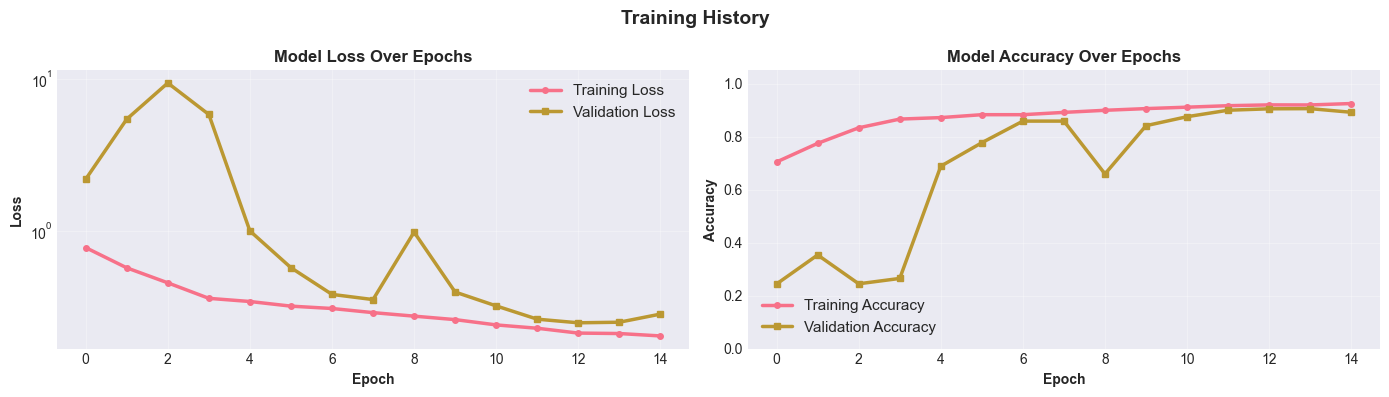

✓ Training history visualized


In [8]:
# ============================================================================
# VISUALIZE: Training History
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss plot
ax = axes[0]
ax.plot(history.history['loss'], label='Training Loss', linewidth=2.5, marker='o', markersize=4)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, marker='s', markersize=4)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Loss', fontweight='bold')
ax.set_title('Model Loss Over Epochs', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Accuracy plot
ax = axes[1]
ax.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2.5, marker='o', markersize=4)
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Model Accuracy Over Epochs', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("✓ Training history visualized")

## 8. Model Evaluation

Evaluate model on test set with comprehensive metrics.


MODEL EVALUATION ON TEST SET

Generating predictions on test set...

✓ Test Accuracy: 0.8225 (82.25%)

----------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

      glioma     0.9468    0.6225    0.7511       400
  meningioma     0.7358    0.7450    0.7404       400
     notumor     0.8163    0.9775    0.8896       400
   pituitary     0.8344    0.9450    0.8863       400

    accuracy                         0.8225      1600
   macro avg     0.8333    0.8225    0.8169      1600
weighted avg     0.8333    0.8225    0.8169      1600



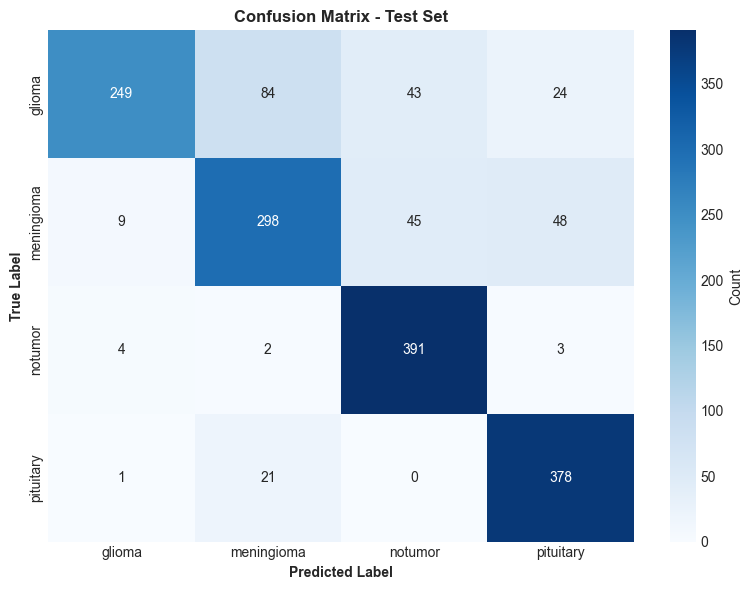


✓ Evaluation complete


In [9]:
# ============================================================================
# MODEL EVALUATION
# ============================================================================

print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)

# Make predictions
print("\nGenerating predictions on test set...")
y_pred_probabilities = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test_encoded, y_pred_classes)

print(f"\n✓ Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification report
print(f"\n" + "-"*70)
print("DETAILED CLASSIFICATION REPORT")
print("-"*70)
print(classification_report(
    y_test_encoded, y_pred_classes,
    target_names=label_encoder.classes_,
    digits=4
))

# Confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred_classes)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'},
    ax=ax
)
ax.set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete")

## 9. Grad-CAM Implementation

Implement Gradient-weighted Class Activation Maps for model interpretability.

### How Grad-CAM Works

1. **Forward Pass**: Input image → Conv layer outputs
2. **Backward Pass**: Compute gradients of predicted class w.r.t. conv layer
3. **Weighting**: Weight conv channels by their gradients
4. **Heatmap**: Average weighted feature maps to create saliency map
5. **Normalization**: Scale heatmap to [0, 1] range

### Output Interpretation
- **Red**: Important regions for prediction (high activation)
- **Yellow/Green**: Medium importance
- **Blue**: Unimportant regions (low activation)

In [10]:
# ============================================================================
# GRAD-CAM IMPLEMENTATION
# ============================================================================

def generate_gradcam_heatmap(model, image_array, conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for model interpretability.
    
    This function computes which regions of an image the model considers
    important when making its prediction.
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained Keras model (must use Functional API)
    image_array : np.ndarray
        Single image of shape (H, W, C) or (1, H, W, C)
    conv_layer_name : str
        Name of convolutional layer to visualize
    pred_index : int, optional
        Target class index. If None, use predicted class.
    
    Returns:
    --------
    heatmap : np.ndarray
        Normalized heatmap of shape (H_conv, W_conv)
    predictions : np.ndarray
        Class probabilities
    """
    # ===== STEP 1: Prepare input =====
    # Ensure input is 4D (batch_size, height, width, channels)
    if len(image_array.shape) == 3:
        img_batch = np.expand_dims(image_array, axis=0)
    else:
        img_batch = image_array
    
    # ===== STEP 2: Create sub-model =====
    # Map from input to [conv_output, model_output]
    conv_layer = model.get_layer(conv_layer_name)
    
    sub_model = Model(
        inputs=model.input,
        outputs=[conv_layer.output, model.output]
    )
    
    # ===== STEP 3: Compute gradients =====
    with tf.GradientTape() as tape:
        # Forward pass through sub-model
        conv_output, predictions = sub_model(img_batch, training=False)
        
        # Determine target class
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        
        # Extract score for target class
        class_score = predictions[0, pred_index]
    
    # Compute gradients of class score w.r.t. conv output
    gradients = tape.gradient(class_score, conv_output)
    
    # ===== STEP 4: Pool gradients over spatial dimensions =====
    # Average gradients across height and width
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    
    # ===== STEP 5: Weight conv channels by gradients =====
    conv_output = conv_output[0]  # Remove batch dimension
    heatmap = tf.reduce_sum(conv_output * pooled_gradients, axis=-1)
    
    # ===== STEP 6: Normalize heatmap =====
    # Apply ReLU to keep only positive activations
    heatmap = tf.nn.relu(heatmap)
    
    # Normalize to [0, 1]
    max_heat = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_heat + 1e-8)
    
    return heatmap.numpy(), predictions.numpy()[0]

print("✓ Grad-CAM function ready!")

✓ Grad-CAM function ready!


## 10. Grad-CAM Visualization

Generate and display Grad-CAM heatmaps for sample test images.


GRAD-CAM VISUALIZATION

Generating Grad-CAM heatmaps for 4 test images...

[1/4] Processing glioma... ✓
[2/4] Processing glioma... ✓
[3/4] Processing pituitary... ✓
[4/4] Processing glioma... ✓


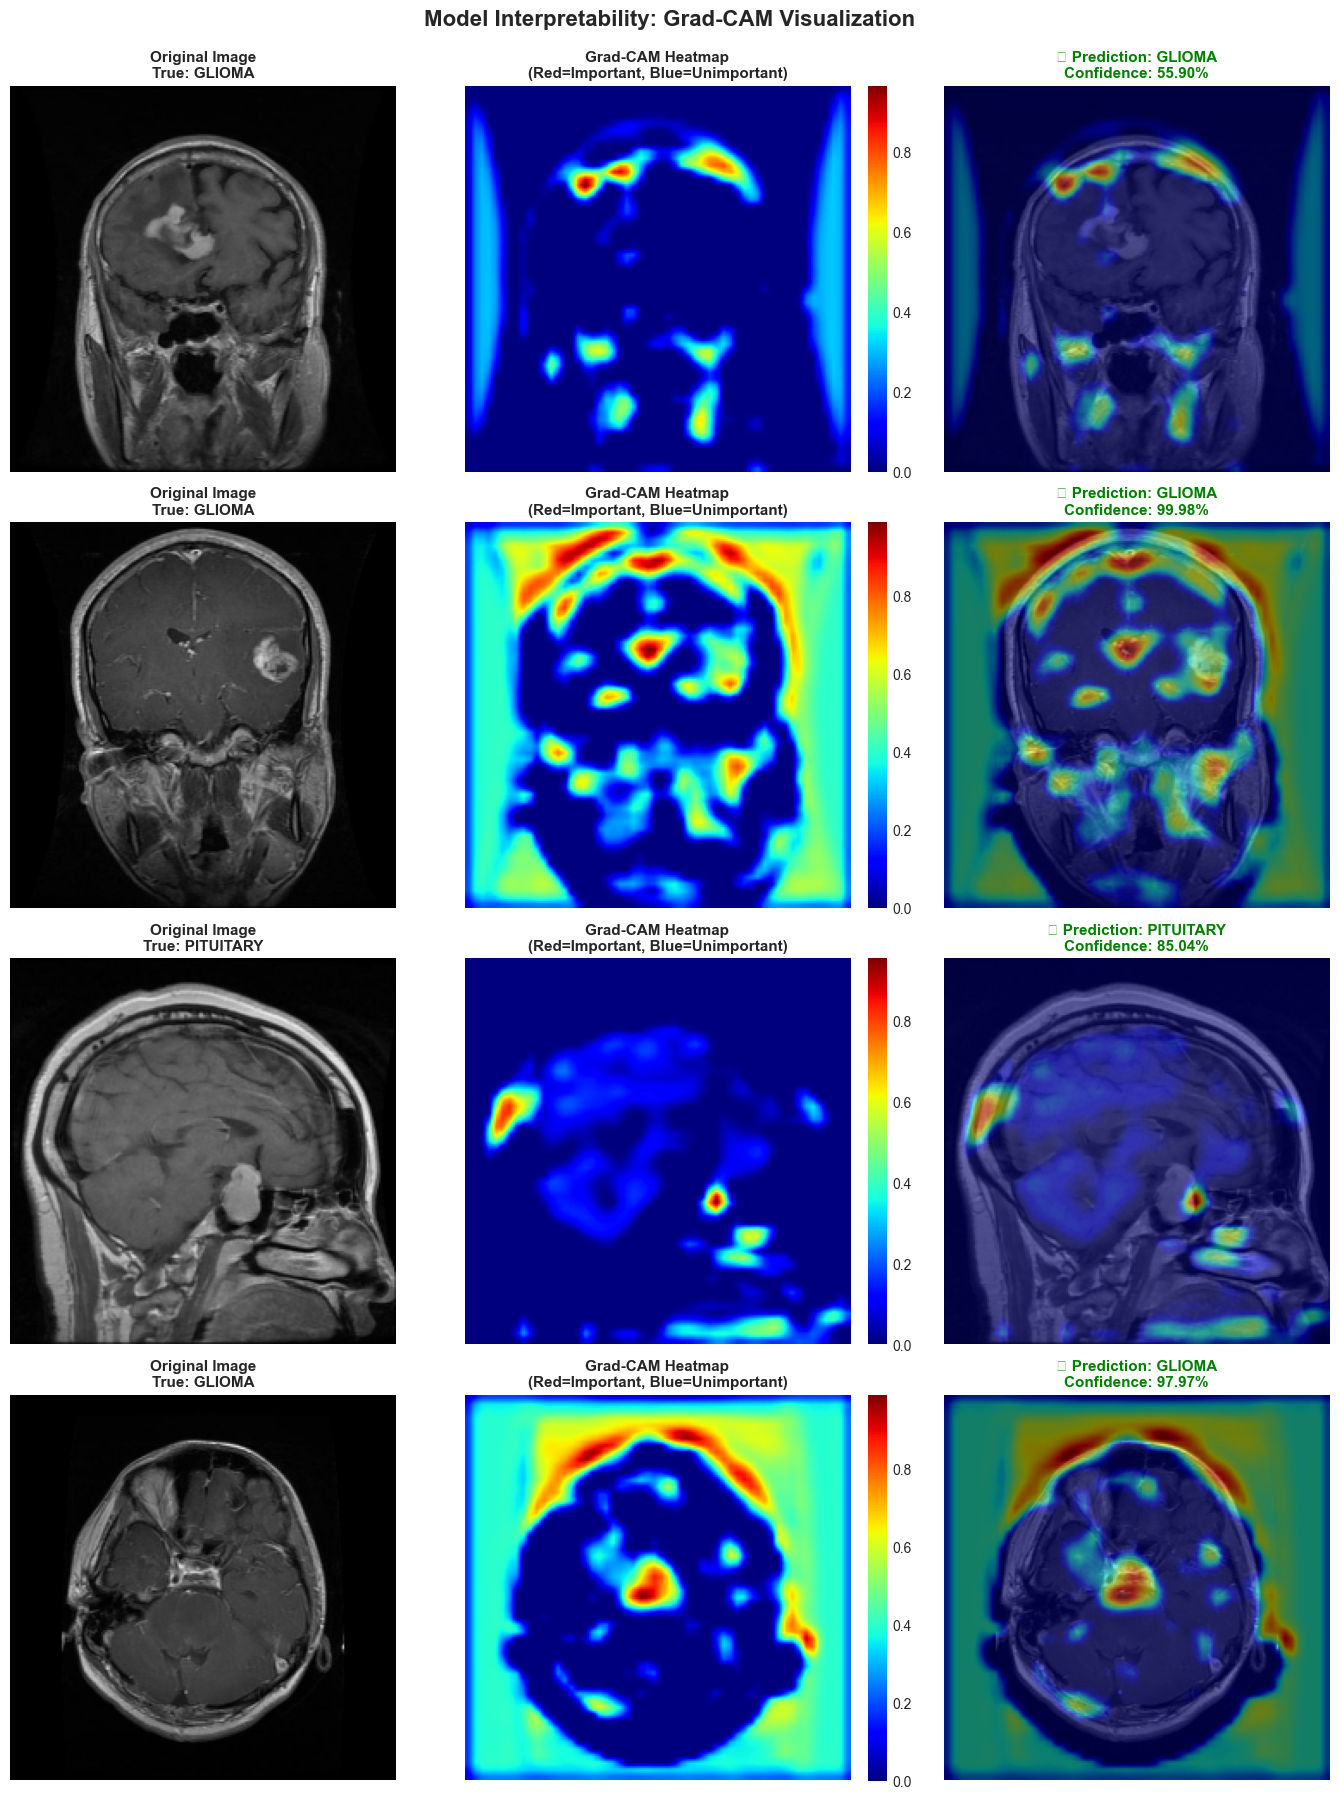


✓ Grad-CAM visualization complete!


In [11]:
# ============================================================================
# VISUALIZE: Grad-CAM HEATMAPS
# ============================================================================

print("\n" + "="*70)
print("GRAD-CAM VISUALIZATION")
print("="*70)
print(f"\nGenerating Grad-CAM heatmaps for {NUM_GRADCAM_SAMPLES} test images...\n")

fig, axes = plt.subplots(
    NUM_GRADCAM_SAMPLES, 3,
    figsize=(14, 4.5*NUM_GRADCAM_SAMPLES)
)

fig.suptitle(
    'Model Interpretability: Grad-CAM Visualization',
    fontsize=16,
    fontweight='bold',
    y=0.995
)

# Select diverse test samples
sample_indices = np.linspace(
    0, len(X_test)-1, NUM_GRADCAM_SAMPLES, dtype=int
)

for row, img_idx in enumerate(sample_indices):
    # Get image and true label
    img = X_test[img_idx]
    true_label_idx = y_test_encoded[img_idx]
    true_label = label_encoder.classes_[true_label_idx]
    
    # Get prediction
    pred_probs = y_pred_probabilities[img_idx]
    pred_idx = np.argmax(pred_probs)
    pred_label = label_encoder.classes_[pred_idx]
    confidence = pred_probs[pred_idx]
    is_correct = (true_label == pred_label)
    
    # Generate Grad-CAM
    print(f"[{row+1}/{NUM_GRADCAM_SAMPLES}] Processing {true_label}...", end="")
    heatmap, _ = generate_gradcam_heatmap(
        model, img, GRADCAM_LAYER_NAME, pred_index=pred_idx
    )
    print(" ✓")
    
    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(
        heatmap,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_LINEAR
    )
    
    # ===== Column 1: Original Image =====
    ax = axes[row, 0]
    ax.imshow(img, cmap='gray')
    ax.set_title(
        f'Original Image\nTrue: {true_label.upper()}',
        fontsize=11,
        fontweight='bold'
    )
    ax.axis('off')
    
    # ===== Column 2: Grad-CAM Heatmap =====
    ax = axes[row, 1]
    im = ax.imshow(heatmap_resized, cmap='jet')
    ax.set_title(
        f'Grad-CAM Heatmap\n(Red=Important, Blue=Unimportant)',
        fontsize=11,
        fontweight='bold'
    )
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # ===== Column 3: Overlay =====
    ax = axes[row, 2]
    ax.imshow(img, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.5)
    
    # Determine correctness indicator
    correct_symbol = "✅" if is_correct else "❌"
    
    ax.set_title(
        f'{correct_symbol} Prediction: {pred_label.upper()}\nConfidence: {confidence:.2%}',
        fontsize=11,
        fontweight='bold',
        color='green' if is_correct else 'red'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Grad-CAM visualization complete!")

## 11. Model Analysis & Interpretation

Detailed analysis of model performance and failure cases.

In [12]:
# ============================================================================
# PERFORMANCE ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*70)

# Per-class performance
print(f"\nPer-Class Metrics:")
for class_idx, class_name in enumerate(label_encoder.classes_):
    class_mask = y_test_encoded == class_idx
    class_correct = np.sum((y_pred_classes == class_idx) & class_mask)
    class_total = np.sum(class_mask)
    class_acc = class_correct / class_total if class_total > 0 else 0
    
    print(f"  {class_name:12s}: {class_correct}/{class_total} correct ({class_acc:.2%})")

# Misclassified samples
misclassified_mask = y_pred_classes != y_test_encoded
misclassified_count = np.sum(misclassified_mask)

print(f"\nMisclassification Analysis:")
print(f"  Total misclassified: {misclassified_count}/{len(y_test_encoded)} ({(misclassified_count/len(y_test_encoded))*100:.2f}%)")

if misclassified_count > 0:
    print(f"\n  Misclassification Details:")
    for i in range(min(5, misclassified_count)):
        idx = np.where(misclassified_mask)[0][i]
        true_label = label_encoder.classes_[y_test_encoded[idx]]
        pred_label = label_encoder.classes_[y_pred_classes[idx]]
        confidence = y_pred_probabilities[idx][y_pred_classes[idx]]
        print(f"    - {true_label} predicted as {pred_label} (conf: {confidence:.2%})")


DETAILED PERFORMANCE ANALYSIS

Per-Class Metrics:
  glioma      : 249/400 correct (62.25%)
  meningioma  : 298/400 correct (74.50%)
  notumor     : 391/400 correct (97.75%)
  pituitary   : 378/400 correct (94.50%)

Misclassification Analysis:
  Total misclassified: 284/1600 (17.75%)

  Misclassification Details:
    - glioma predicted as notumor (conf: 59.17%)
    - meningioma predicted as pituitary (conf: 55.92%)
    - meningioma predicted as notumor (conf: 85.07%)
    - glioma predicted as notumor (conf: 96.96%)
    - meningioma predicted as notumor (conf: 65.57%)


## 12. Summary & Conclusions

In [13]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

PROGRAM_END = time.perf_counter()
total_time = PROGRAM_END - PROGRAM_START

print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"\n📊 DATASET STATISTICS:")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples: {len(X_test)}")
print(f"  Image dimensions: {IMG_SIZE}×{IMG_SIZE}×{IMG_CHANNELS}")
print(f"  Number of classes: {NUM_CLASSES}")

print(f"\n🏗️  MODEL ARCHITECTURE:")
print(f"  Total parameters: {model.count_params():,}")
print(f"  Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"  Conv layers: 6 ")
print(f"  Dense layers: 2 ")

print(f"\n📈 TRAINING RESULTS:")
print(f"  Epochs trained: {actual_epochs}")
print(f"  Training time: {training_time:.2f} seconds")
print(f"  Final training loss: {history.history['loss'][-1]:.4f}")
print(f"  Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Final validation loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

print(f"\n🎯 TEST SET PERFORMANCE:")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Misclassified samples: {misclassified_count}/{len(y_test_encoded)}")

print(f"\n🔍 GRAD-CAM VISUALIZATION:")
print(f"  Layer analyzed: {GRADCAM_LAYER_NAME}")
print(f"  Number of feature maps: 128")
print(f"  Spatial resolution: 16×16")
print(f"  Interpretation:")
print(f"    🔴 Red regions = Important for prediction")
print(f"    🟡 Yellow/Green regions = Moderately important")
print(f"    🔵 Blue regions = Not important")

print(f"\n⏱️  EXECUTION TIME:")
print(f"  Total time: {total_time:.2f} seconds")
print(f"  Data loading & preprocessing: ~{(total_time * 0.1):.2f}s")
print(f"  Model training: {training_time:.2f}s")
print(f"  Evaluation & visualization: ~{(total_time * 0.15):.2f}s")

print(f"\n💡 KEY FINDINGS:")
if test_accuracy > 0.85:
    print(f"  ✅ Model shows strong performance (>85% accuracy)")
elif test_accuracy > 0.75:
    print(f"  ⚠️  Model shows good performance (>75% accuracy)")
else:
    print(f"  ⚠️  Model could benefit from improvement")
    
print(f"  ✅ Grad-CAM provides interpretable visualizations")


PROJECT SUMMARY

📊 DATASET STATISTICS:
  Training samples: 5600
  Testing samples: 1600
  Image dimensions: 224×224×3
  Number of classes: 4

🏗️  MODEL ARCHITECTURE:
  Total parameters: 872,996
  Trainable parameters: 871,588
  Conv layers: 6 
  Dense layers: 2 

📈 TRAINING RESULTS:
  Epochs trained: 15
  Training time: 7449.35 seconds
  Final training loss: 0.2044
  Final training accuracy: 0.9247
  Final validation loss: 0.2846
  Final validation accuracy: 0.8917

🎯 TEST SET PERFORMANCE:
  Test Accuracy: 0.8225 (82.25%)
  Misclassified samples: 284/1600

🔍 GRAD-CAM VISUALIZATION:
  Layer analyzed: last_conv
  Number of feature maps: 128
  Spatial resolution: 16×16
  Interpretation:
    🔴 Red regions = Important for prediction
    🟡 Yellow/Green regions = Moderately important
    🔵 Blue regions = Not important

⏱️  EXECUTION TIME:
  Total time: 7507.41 seconds
  Data loading & preprocessing: ~750.74s
  Model training: 7449.35s
  Evaluation & visualization: ~1126.11s

💡 KEY FINDINGS:


## Possible Improvements

Several preprocessing and modeling improvements could make the system stronger. First, cropping MRI images to remove empty black background space can help the network focus more directly on the brain region and reduce distraction from irrelevant pixels. This may improve feature quality and model efficiency.

Second, stronger data augmentation can make the model more robust. Applying controlled transformations such as small rotations, width and height shifts, zoom, brightness variation, and horizontal or vertical flips can increase training diversity and reduce overfitting by exposing the model to more realistic variations.

Third, increasing the number of convolutional layers may improve the model's ability to learn more complex patterns. However, adding more layers does not automatically guarantee better results, because a deeper network can also increase overfitting, training time, and computational cost if it is not supported by enough data and proper regularization.

## Future Work

Further improvement could be achieved by combining image cropping, stronger augmentation, and architecture tuning. Other useful directions include transfer learning with pretrained models such as ResNet or EfficientNet, learning-rate scheduling, better test-set verification, and more advanced MRI preprocessing such as skull stripping or region-of-interest extraction. 

Overall, the current model is well-structured and already achieves strong validation performance, but there is still room to improve generalization, robustness, and medical reliability through better preprocessing and more careful model optimization.